# Notebook 3. The kernel on its own

**The question.** Can `A_t`, `S_t` and `R_t` by themselves tell us when a run will grok?

Notebooks 1 and 2 always gave the models the settings (`alpha`, width and weight decay). The settings are a shortcut. The seeds of one cell behave almost the same, so a model can learn "this mix of settings groks around step X" and never look at the kernel. Here the models get **only the kernel**, read at step 2,430, before any run groks.

**The test.** We hide one whole value of `alpha`, train on the other two, and predict the hidden one. The model has never seen runs like these. If the kernel carries a real signal, it should still rank them.

**The ladder.**
1. A linear AFT on the three numbers.
2. The same with interaction terms (the product of two numbers).
3. Two non-linear models: kernel ridge regression and XGBoost.

**Short answer.**
- Each number alone does about as well as a coin toss on a hidden `alpha` (0.50 to 0.55).
- A straight line on all three ties width and weight decay (0.550 against 0.549). Adding interactions lifts it to 0.631.
- XGBoost reaches 0.742 and wins on every hidden `alpha`. The signal is there, but it is curved.

### Words you need

| Word | What it means |
| --- | --- |
| grokked | The test accuracy reached 0.95. The **grokking step** `T` is the first step where that happens (report §3.5). |
| censored | The run never reached 0.95 within 200,000 steps. We keep it, and we know only that `T` is over 200,000. |
| cell | One mix of `alpha`, width and weight decay. Each cell has 5 seeds. |
| `S_t`, `R_t`, `A_t` | How much the kernel has grown, how much it has turned, and how well it lines up with the labels (report Eq. 6). |
| interaction | The product of two numbers, such as `S_t × R_t`. It lets the effect of one number depend on the other. |
| concordance | Pick two runs. How often does the model say the right one groks first? 0.5 is a coin toss and 1 is perfect. |

**One gap from the report.** Every run uses the same train/test split (data seed 42), while the report gives each seed its own (§3.1).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import chi2
from lifelines import LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, GroupKFold

plt.style.use('fitting.mplstyle')
GREY, INK = '#8a8984', '#0b0b0b'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06'}
kernel = ['A_t', 'S_t', 'R_t']
pairs = [('A_t', 'S_t'), ('A_t', 'R_t'), ('S_t', 'R_t')]
LANDMARK = 2_430

## Load the data

The same runs as notebook 2: every weight decay level up to 1e-3, so 630 runs.

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'train_acc', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

events = runs.set_index('run_id')
events['t_gen95'] = acc[acc['test_acc'] >= 0.95].groupby('run_id')['step'].min()
events = events.reset_index()
events['grokked'] = events['t_gen95'].notna().astype(int)     # 1 = grokked, 0 = censored
events['T'] = events['t_gen95'].fillna(events['last_step'])    # the grokking step, or 200,000 if censored
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

data = events.merge(kern[kern['step'] == LANDMARK].drop(columns='step'), on='run_id')
data = data[data['eta_kappa'] <= 1e-3].reset_index(drop=True)
assert data['T'].min() > LANDMARK     # no run has grokked when we read the kernel
pd.Series({'runs': len(data), 'grokked': data['grokked'].sum(), 'censored': (1 - data['grokked']).sum()})

runs        630
grokked     355
censored    275
dtype: int64

## Part 1. What the kernel looks like at the landmark

Each dot is one run. Filled dots grokked, and their height is the grokking step. Hollow dots at the top never grokked.

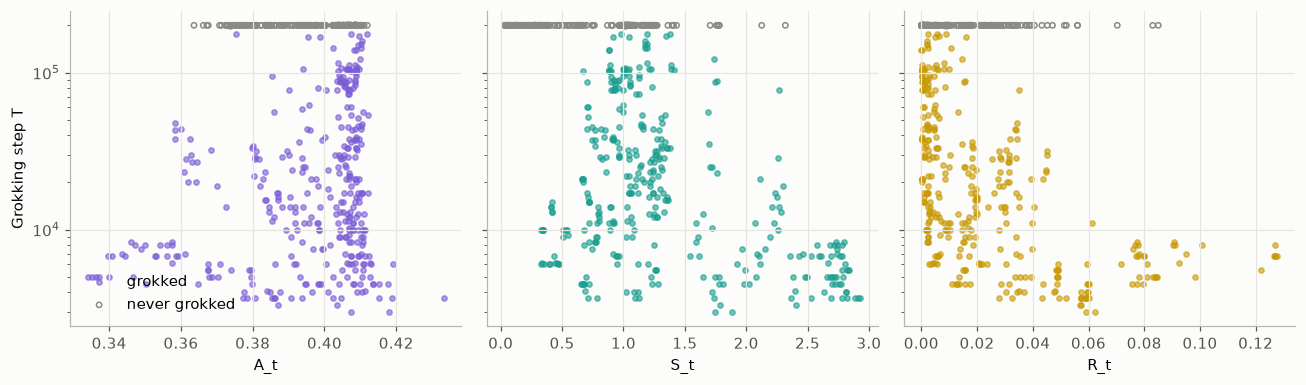

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, number in zip(axes, kernel):
    g, c = data[data['grokked'] == 1], data[data['grokked'] == 0]
    ax.scatter(g[number], g['T'], s=12, color=KERNEL_COLOURS[number], alpha=0.6, label='grokked')
    ax.scatter(c[number], c['T'], s=12, facecolors='none', edgecolors=GREY, label='never grokked')
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Grokking step T')
axes[0].legend(loc='lower left')
plt.tight_layout()
plt.show()

The three numbers also move together. A correlation near 1 or -1 means two numbers say almost the same thing.

In [4]:
data[kernel].corr().round(2)

,A_t,S_t,R_t
A_t,1.00,-0.38,-0.68
S_t,-0.38,1.00,0.55
R_t,-0.68,0.55,1.00


And here is how they differ between the values of `alpha`. If one `alpha` sits in its own corner, a model trained on the other two has to stretch to reach it.

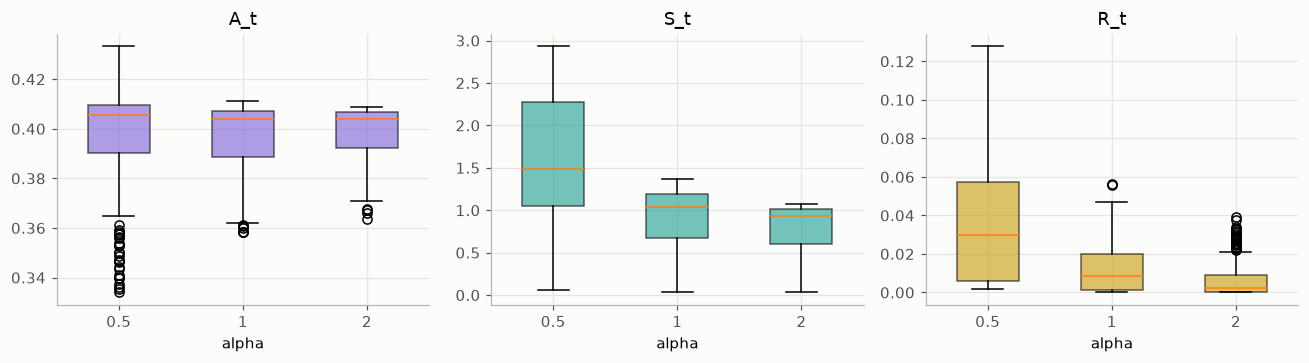

,A_t,S_t,R_t
alpha,,,
0.5,0.405,1.487,0.030
1.0,0.404,1.039,0.008
2.0,0.404,0.930,0.002


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, number in zip(axes, kernel):
    box = ax.boxplot([g[number] for _, g in data.groupby('alpha')], tick_labels=['0.5', '1', '2'], patch_artist=True, widths=0.5)
    for patch in box['boxes']:
        patch.set_facecolor(KERNEL_COLOURS[number])
        patch.set_alpha(0.6)
    ax.set_xlabel('alpha')
    ax.set_title(number)
plt.tight_layout()
plt.show()
data.groupby('alpha')[kernel].median().round(3)

**Takeaway**
- `A_t` and `R_t` move together strongly (correlation -0.68), so the model can struggle to split their effects.
- `A_t` looks the same for every `alpha` at the landmark (median 0.40). `S_t` and `R_t` are smaller for bigger `alpha`, since a lazier network moves its kernel less.
- At `alpha` 2 the kernel has barely moved (median `R_t` 0.002). A model trained on `alpha` 0.5 and 1 has to guess outside what it has seen.

## Part 2. Which numbers matter, and how sure are we?

We fit the AFT on all 630 runs. The AFT is linear regression on log `T` that also uses "at least 200,000" for the runs that never grok (report Eq. 10). Each number is scaled to mean 0 and spread 1, so the coefficients compare fairly. A coefficient `a` multiplies the median grokking step by e^a for one spread more of that number. A negative `a` means sooner.

We fit it twice: with the three numbers alone, and with the three interactions added.

In [6]:
z = (data[kernel] - data[kernel].mean()) / data[kernel].std()
X_main = z.copy()
X_inter = z.copy()
for a, b in pairs:
    X_inter[f'{a} × {b}'] = z[a] * z[b]

fit_main = LogNormalAFTFitter().fit(X_main.assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
fit_inter = LogNormalAFTFitter().fit(X_inter.assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
table = fit_inter.summary.loc['mu_'].drop('Intercept')[['coef', 'exp(coef)', 'p']]
table.columns = ['coef a', 'times the median', 'p']
table.round(3)

,coef a,times the median,p
covariate,,,
A_t,-0.654,0.520,0.000
A_t × R_t,-0.490,0.613,0.000
A_t × S_t,0.609,1.839,0.000
R_t,-0.837,0.433,0.000
S_t,-0.728,0.483,0.000
S_t × R_t,-0.097,0.908,0.386


### Do the interactions help?

The likelihood ratio test asks if the extra three terms fit the data better than chance would allow.

In [7]:
lr = 2 * (fit_inter.log_likelihood_ - fit_main.log_likelihood_)
pd.Series({'LR statistic': lr, 'extra terms': 3, 'p': chi2.sf(lr, 3)}).round(4)

LR statistic    37.8555
extra terms      3.0000
p                0.0000
dtype: float64

### A fairer error bar

The p-values above treat all 630 runs as independent. They aren't: the 5 seeds of a cell are near copies. So we redo the fit 300 times, each time drawing whole cells at random with replacement. The spread of the coefficients over those fits gives an honest 95% range.

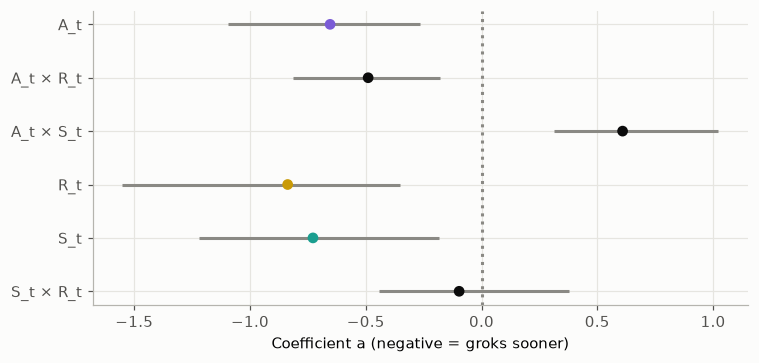

,coef a,lower 95%,upper 95%,range excludes 0
covariate,,,,
A_t,-0.654,-1.094,-0.267,True
A_t × R_t,-0.490,-0.816,-0.178,True
A_t × S_t,0.609,0.315,1.022,True
R_t,-0.837,-1.551,-0.354,True
S_t,-0.728,-1.222,-0.183,True
S_t × R_t,-0.097,-0.442,0.378,False


In [8]:
rng = np.random.default_rng(0)
cells = data['cell'].unique()
boot = []
for _ in range(300):
    pick = rng.choice(cells, size=len(cells), replace=True)
    rows = np.concatenate([np.flatnonzero(data['cell'] == c) for c in pick])
    f = LogNormalAFTFitter(penalizer=1e-4).fit(X_inter.iloc[rows].reset_index(drop=True).assign(T=data['T'].iloc[rows].to_numpy(), grokked=data['grokked'].iloc[rows].to_numpy()), 'T', 'grokked')
    boot.append(f.params_.loc['mu_'].drop('Intercept'))
boot = pd.DataFrame(boot)
ranges = pd.DataFrame({'coef a': table['coef a'], 'lower 95%': boot.quantile(0.025), 'upper 95%': boot.quantile(0.975)})
ranges['range excludes 0'] = (ranges['lower 95%'] > 0) | (ranges['upper 95%'] < 0)

fig, ax = plt.subplots(figsize=(7, 3.4))
colours = [KERNEL_COLOURS.get(name, INK) for name in ranges.index]
ax.errorbar(ranges['coef a'], range(len(ranges)), xerr=[ranges['coef a'] - ranges['lower 95%'], ranges['upper 95%'] - ranges['coef a']],
            fmt='none', ecolor=GREY)
ax.scatter(ranges['coef a'], range(len(ranges)), color=colours, zorder=3)
ax.axvline(0, color=GREY, linestyle=':')
ax.set_yticks(range(len(ranges)), ranges.index)
ax.invert_yaxis()
ax.set_xlabel('Coefficient a (negative = groks sooner)')
plt.tight_layout()
plt.show()
ranges.round(3)

**Takeaway**
- All three numbers have negative coefficients. A run whose kernel has grown more, turned more, or lined up better with the labels groks sooner.
- `A_t × S_t` (+0.61) and `A_t × R_t` (-0.49) matter. `S_t × R_t` does not (p = 0.39). Together the interactions fit better than chance would allow (likelihood ratio 37.9, p < 0.0001).
- Every range except `S_t × R_t` stays clear of 0, even when we resample whole cells.
- These are links across all runs. They don't yet tell us the model can predict new runs. Part 3 tests that.
- Product terms in a straight line can also stand in for curves, since the numbers are correlated. Notebook 4 (Part 6) separates the two.

## Part 3. Can it predict an `alpha` it has never seen?

Now the real test. For each value of `alpha` we train on the other two and predict the hidden one. The scaling of the numbers is learned from the training runs only.

We start with the two linear AFTs and each number on its own.

In [9]:
linear_models = {'A_t only': ['A_t'], 'S_t only': ['S_t'], 'R_t only': ['R_t'],
                 'linear AFT': list(X_main), 'linear AFT + interactions': list(X_inter)}
pred = pd.DataFrame(index=data.index)
for a in sorted(data['alpha'].unique()):
    train, test = data['alpha'] != a, data['alpha'] == a
    z = (data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()
    X = z.copy()
    for p, q in pairs:
        X[f'{p} × {q}'] = z[p] * z[q]
    for name, cols in linear_models.items():
        aft = LogNormalAFTFitter(penalizer=0.01).fit(X.loc[train, cols].assign(T=data['T'], grokked=data['grokked']), 'T', 'grokked')
        pred.loc[test, name] = aft.predict_median(X.loc[test, cols]).to_numpy().ravel()

### The non-linear models

A straight line (even with interactions) can only bend in a few set ways. These two models can learn any shape.

- **Kernel ridge regression** draws a smooth curved surface through the data. It predicts log `T`, so like plain linear regression it only trains on runs that grokked. We tune its smoothness inside the training runs, holding out whole cells.
- **XGBoost** builds many small decision trees, each fixing the mistakes of the ones before. Its `survival:aft` setting uses the same idea as our AFT, so it keeps the runs that never grok as "at least 200,000". Its settings are fixed in advance, not tuned.

In [10]:
XGB_PARAMS = {'objective': 'survival:aft', 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.0,
              'max_depth': 3, 'eta': 0.05, 'min_child_weight': 5, 'subsample': 0.8, 'seed': 0}
log_T = np.log(data['T'])
upper = np.where(data['grokked'] == 1, data['T'], np.inf)     # XGBoost takes the raw step. A censored run's T can be anything above 200,000.

for a in sorted(data['alpha'].unique()):
    train, test = data['alpha'] != a, data['alpha'] == a
    z = (data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()

    g = train & (data['grokked'] == 1)
    krr = GridSearchCV(KernelRidge(kernel='rbf'), {'alpha': [0.01, 0.1, 1], 'gamma': [0.1, 0.5, 2]}, cv=GroupKFold(5))
    krr.fit(z[g], log_T[g], groups=data.loc[g, 'cell'])
    pred.loc[test, 'kernel ridge'] = np.exp(krr.predict(z[test]))

    m = xgb.DMatrix(z[train])
    m.set_float_info('label_lower_bound', data.loc[train, 'T'])
    m.set_float_info('label_upper_bound', upper[train])
    booster = xgb.train(XGB_PARAMS, m, num_boost_round=300)
    pred.loc[test, 'XGBoost'] = booster.predict(xgb.DMatrix(z[test]))

### The scores

We score each hidden `alpha` on its own, then take the mean of the three. For reference, notebook 2 got **0.549** on the same test with width and weight decay and no kernel.

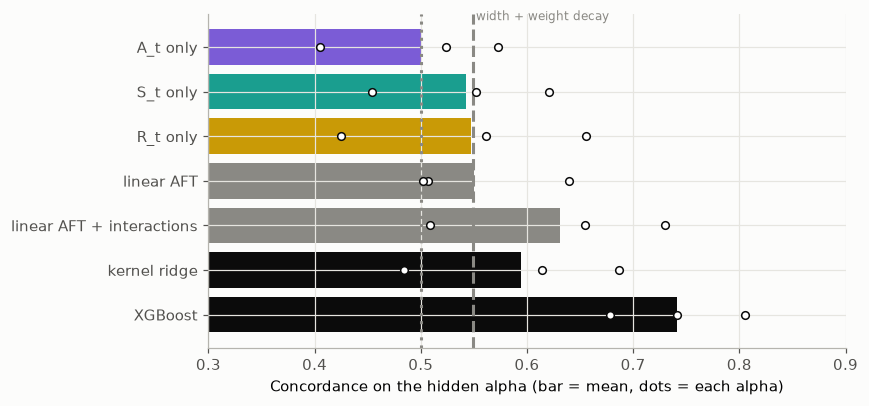

,alpha 0.5,alpha 1,alpha 2,mean
A_t only,0.573,0.524,0.405,0.501
S_t only,0.621,0.552,0.454,0.542
R_t only,0.655,0.561,0.425,0.547
linear AFT,0.639,0.507,0.503,0.550
linear AFT + interactions,0.730,0.509,0.654,0.631
kernel ridge,0.686,0.614,0.484,0.595
XGBoost,0.741,0.679,0.805,0.742


In [11]:
scores = {}
for name in pred:
    scores[name] = {f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], pred.loc[data['alpha'] == a, name],
                                                      data.loc[data['alpha'] == a, 'grokked'])
                    for a in sorted(data['alpha'].unique())}
scores = pd.DataFrame(scores).T
scores['mean'] = scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 3.8))
colours = [KERNEL_COLOURS['A_t'], KERNEL_COLOURS['S_t'], KERNEL_COLOURS['R_t'], GREY, GREY, INK, INK]
ax.barh(scores.index, scores['mean'], color=colours)
for i, (name, row) in enumerate(scores.iterrows()):
    ax.scatter(row[['alpha 0.5', 'alpha 1', 'alpha 2']], [i] * 3, color='white', edgecolors=INK, s=25, zorder=3)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.axvline(0.549, color=GREY, linestyle='--')
ax.text(0.552, -0.6, 'width + weight decay', color=GREY, fontsize=8)
ax.set_xlim(0.3, 0.9)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the hidden alpha (bar = mean, dots = each alpha)')
plt.tight_layout()
plt.show()
scores.round(3)

### Was XGBoost lucky?

XGBoost picks random subsets of runs as it trains. We rerun it with 5 different random seeds to check the score doesn't hang on one draw.

In [12]:
seed_scores = {}
for seed in range(5):
    row = {}
    for a in sorted(data['alpha'].unique()):
        train, test = data['alpha'] != a, data['alpha'] == a
        z = (data[kernel] - data.loc[train, kernel].mean()) / data.loc[train, kernel].std()
        m = xgb.DMatrix(z[train])
        m.set_float_info('label_lower_bound', data.loc[train, 'T'])
        m.set_float_info('label_upper_bound', upper[train])
        booster = xgb.train({**XGB_PARAMS, 'seed': seed}, m, num_boost_round=300)
        row[f'alpha {a:g}'] = concordance_index(data.loc[test, 'T'], booster.predict(xgb.DMatrix(z[test])), data.loc[test, 'grokked'])
    seed_scores[f'seed {seed}'] = row
seed_scores = pd.DataFrame(seed_scores).T
seed_scores['mean'] = seed_scores.mean(axis=1)
seed_scores.round(3)

,alpha 0.5,alpha 1,alpha 2,mean
seed 0,0.741,0.679,0.805,0.742
seed 1,0.744,0.694,0.822,0.753
seed 2,0.742,0.671,0.813,0.742
seed 3,0.743,0.653,0.819,0.738
seed 4,0.746,0.656,0.813,0.738


**Takeaway**
- Single numbers sit near 0.5 on average. Each one helps on one `alpha` and fails on another.
- The linear AFT (0.550) ties width and weight decay (0.549). Interactions lift it to 0.631.
- These models include the runs that never grok. Notebook 4 (Part 6) shows interactions help here in every model family, mostly because they help tell runs that grok from runs that never do. Among runs that grok, interactions add almost nothing.
- Kernel ridge (0.595) falls apart on `alpha` 2 (0.484). It trains on grokked runs only and has to reach outside its data.
- XGBoost is best on every hidden `alpha`, with a mean of 0.742. The 5 seeds give 0.738 to 0.753, so it isn't luck.
- So there is more than meets the eye. The kernel's link to grokking is curved, and a straight line misses most of it.

## Part 4. What shape did XGBoost find?

We train XGBoost once on all the runs. Then we slide one number from low to high, keep the other two at their median, and watch the predicted grokking step. A flat line means the number does nothing on its own.

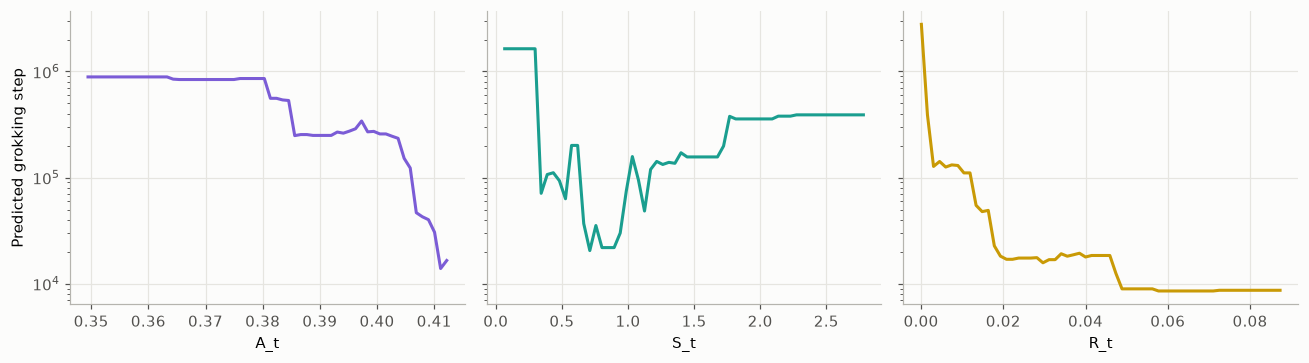

In [13]:
z = (data[kernel] - data[kernel].mean()) / data[kernel].std()
m = xgb.DMatrix(z)
m.set_float_info('label_lower_bound', data['T'])
m.set_float_info('label_upper_bound', upper)
booster = xgb.train(XGB_PARAMS, m, num_boost_round=300)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, number in zip(axes, kernel):
    grid = np.linspace(z[number].quantile(0.02), z[number].quantile(0.98), 60)
    probe = pd.DataFrame({c: np.full(60, z[c].median()) for c in kernel})
    probe[number] = grid
    ax.plot(grid * data[number].std() + data[number].mean(), booster.predict(xgb.DMatrix(probe)), color=KERNEL_COLOURS[number])
    ax.set_yscale('log')
    ax.set_xlabel(number)
axes[0].set_ylabel('Predicted grokking step')
plt.tight_layout()
plt.show()

### Two numbers at once

This map holds `A_t` at its median and varies `S_t` and `R_t` together. Darker means a later grokking step. If the colour bands run straight across, the two numbers act separately. If they bend, the effect of one depends on the other, which is an interaction.

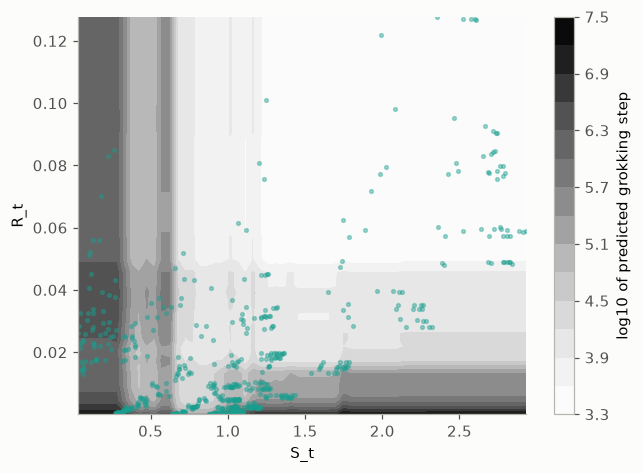

In [14]:
s_grid = np.linspace(z['S_t'].min(), z['S_t'].max(), 60)
r_grid = np.linspace(z['R_t'].min(), z['R_t'].max(), 60)
S, R = np.meshgrid(s_grid, r_grid)
probe = pd.DataFrame({'A_t': z['A_t'].median(), 'S_t': S.ravel(), 'R_t': R.ravel()})
surface = booster.predict(xgb.DMatrix(probe)).reshape(S.shape)

fig, ax = plt.subplots(figsize=(6, 4.4))
im = ax.contourf(S * data['S_t'].std() + data['S_t'].mean(), R * data['R_t'].std() + data['R_t'].mean(), np.log10(surface), levels=12, cmap='Greys')
ax.scatter(data['S_t'], data['R_t'], s=6, color=KERNEL_COLOURS['S_t'], alpha=0.4)
fig.colorbar(im, label='log10 of predicted grokking step')
ax.set_xlabel('S_t')
ax.set_ylabel('R_t')
ax.grid(False)
plt.tight_layout()
plt.show()

**Takeaway**
- `S_t` has a sweet spot. Kernels that shrank (`S_t` under about 0.3) are predicted never to grok. Runs near `S_t` 0.7 to 1 grok earliest, and runs above 1.7 grok later again. A straight line can't draw that shape.
- `R_t` near 0 means late. Past about 0.05, more turning stops helping.
- Higher `A_t` means sooner, mostly above 0.40.
- A run is predicted to grok early only when `S_t` is above about 0.65 **and** `R_t` is above about 0.005. Needing both is an interaction. It mostly separates runs that never grok from the rest, which matches notebook 4 (Part 6).
- Predicted steps above 200,000 are guesses past the budget. Only their order matters.

## Summary

| Question | Answer |
| --- | --- |
| Does any one number predict a new `alpha`? | No. Each scores 0.50 to 0.55 on average. |
| Are the three numbers linked to grokking? | Yes. All three link to sooner grokking, and the ranges hold when whole cells are resampled. |
| Do interactions matter? | Yes for this question, which counts runs that never grok. `A_t × S_t` and `A_t × R_t` lift the held-out score from 0.550 to 0.631. Notebook 4 shows the gain comes from telling grokkers from non-grokkers. Among runs that grok, interactions add almost nothing. |
| Does a non-linear model find more? | Yes. XGBoost scores 0.742, against 0.549 for width and weight decay. |
| What shape is it? | `S_t` has a sweet spot. `R_t` and `A_t` help up to a point and then level off. |

## Conclusion

On their own, read before any run groks, the three kernel numbers can rank runs from an `alpha` the model has never seen. A straight line hardly finds this. The link is curved, and XGBoost picks it up with a score of 0.742.

Two limits stay. We only hide `alpha`, so the kernel may still be carrying width and weight decay, which the model has seen. Notebook 2 showed that, inside one cell, only `S_t` tells seeds apart. A fair next test is to hide one weight decay level at a time.